# Liesel-GAM Demo Notebook

## Setup and Imports

In [1]:
import jax.numpy as jnp
import liesel.goose as gs
import liesel.model as lsl
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel_gam as gam

In [2]:
# import data from R
from ryp import r, to_py

r("library(mgcv)")
r("data(columb)")
r("data(columb.polys)")

columb = to_py("columb", format="pandas").reset_index()
polys = to_py("columb.polys", format="numpy")

Loading required package: nlme
This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.


In [3]:
columb.head()

,index,area,home.value,income,crime,open.space,district,x,y
0,0,0.309441,80.467003,19.531,15.725980,2.850747,0,8.827218,14.369076
1,1,0.259329,44.567001,21.232,18.801754,5.296720,1,8.332658,14.031624
2,2,0.192468,26.350000,15.956,30.626781,4.534649,2,9.012265,13.819719
3,3,0.083841,33.200001,4.477,32.387760,0.394427,3,8.460801,13.716962
4,4,0.488888,23.225000,11.252,50.731510,0.405664,4,9.007982,13.296366


In [4]:
columb["home_value"] = columb["home.value"]

## Model Definition

### Setup response model

In [5]:
df = columb
tb = gam.TermBuilder.from_df(df)

loc = gam.AdditivePredictor("$\\mu$")
scale = gam.AdditivePredictor("$\\sigma$", inv_link=jnp.exp)


y = lsl.Var.new_obs(
    value=df.crime.to_numpy(),
    distribution=lsl.Dist(tfd.Normal, loc=loc, scale=scale),
    name="y",
)

In [ ]:
loc += tb.fo("area*income + home_value")

### Build and plot model

liesel.model.model - INFO - Converted dtype of Value(name="y_value").value


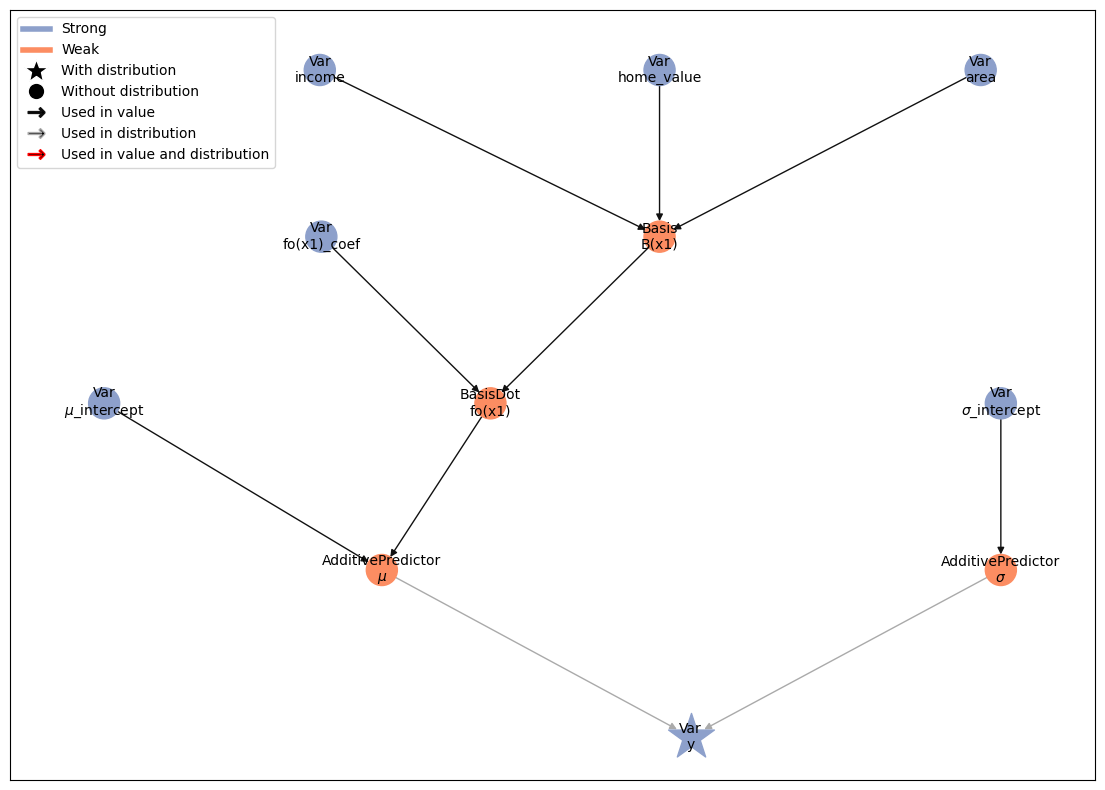

In [7]:
model = lsl.Model([y])
model.plot_vars()

## Run MCMC

In [8]:
eb = gs.LieselMCMC(model).get_engine_builder(seed=1, num_chains=4)

eb.set_epochs(
    gs.stan_epochs(
        warmup_duration=4000,
        posterior_duration=10000,
        init_duration=400,
        term_duration=400,
        thinning_posterior=10,
    )
)
engine = eb.build()
engine.sample_all_epochs()
results = engine.get_results()

liesel.goose.builder - WARNING - No jitter functions provided for position keys '$\\sigma$_intercept', '$\\mu$_intercept', 'fo(x1)_coef'. The initial values for these keys won't be jittered
liesel.goose.engine - INFO - Initializing kernels...
liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 400 transitions, 25 jitted together
100%|████████████████████████████████████████| 16/16 [00:02<00:00,  7.38chunk/s]
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|████████████████████████████████████████| 1/1 [00:00<00:00, 1610.10chunk/s]
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 50 transitions, 25 jitted together
100%|████████████████████████████████████████| 2/2 [00:00<00:00, 1556.33chunk/s]
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTA

### MCMC summary

In [9]:
summary = gs.Summary(results)
summary

Parameter summary:

                             kernel       mean         sd      q_0.05  \
parameter          index                                                
$\mu$_intercept    ()     kernel_01  79.917046   8.980037   65.576704   
$\sigma$_intercept ()     kernel_00   2.442959   0.107698    2.269515   
fo(x1)_coef        (0,)   kernel_02 -54.694836  33.398296 -111.396749   
                   (1,)   kernel_02  -2.271391   0.678552   -3.420895   
                   (2,)   kernel_02  -0.294495   0.106314   -0.470199   
                   (3,)   kernel_02   3.166589   2.371745   -0.735593   

                              q_0.5     q_0.95  sample_size     ess_bulk  \
parameter          index                                                   
$\mu$_intercept    ()     79.444271  95.734858         4000   224.086910   
$\sigma$_intercept ()      2.439140   2.622405         4000  2904.366159   
fo(x1)_coef        (0,)  -54.661430   0.436895         4000   344.311052   
                   (1,)   -2.251050  -1.161386         4000   292.426635   
                   (2,)   -0.294342  -0.121574         4000  1814.815299   
                   (3,)    3.149375   7.133375         4000   286.801148   

                             ess_tail      rhat  
parameter          index                         
$\mu$_intercept    ()      533.519538  1.016733  
$\sigma$_intercept ()     3491.846250  1.000623  
fo(x1)_coef        (0,)    827.153458  1.010791  
                   (1,)    648.550222  1.014182  
                   (2,)   2702.970270  1.001197  
                   (3,)    760.398981  1.012437  

Error summary:

                                                   count  relative
kernel    error_code error_msg           phase                    
kernel_00 90         nan acceptance prob warmup        3  0.000188
                                         posterior     0       0.0

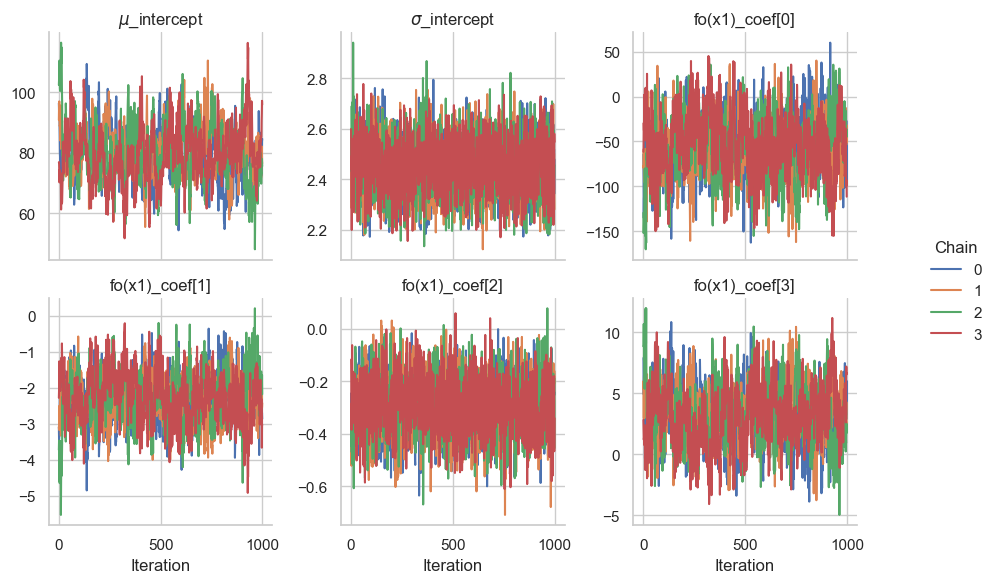

In [10]:
gs.plot_trace(results)